# 03 · Naming phases with a classifier — trees, forests, SHAP

*Name the phases once, then label any new map instantly — and explain why.*

> ⏱ **Runtime:** ~20 s on a laptop CPU (no GPU) · 🎓 **Level:** beginner · 📊 **Data:** Al–Cu map (labels from clustering)

### 🎯 What you'll learn
1. the difference between **unsupervised** and **supervised** learning,
2. a single **decision tree** (readable rules) → **random forest** & **boosting**,
3. why to watch **recall**, not just accuracy, when a phase is **rare** — and **SMOTE**,
4. two ways to ask *which features matter* (**built-in** vs **permutation** importance) and **SHAP**.

### 🧭 What you need to know first
- Notebook **02** (clustering gives us the phase labels to learn from).
- That `H`, `E`, `H/E` describe each indent.

> 🧭 **Supervised vs unsupervised.** Notebook 02 was *unsupervised*: no labels, just
> grouping. Here we go *supervised*: we hand the model example indents **with** phase
> labels and it learns to predict the label of new ones.
> No proprietary data is used — the labels come from clustering the public Al–Cu map.

### Step 0 — set-up

Run the cell below first. In Jupyter you run a cell by clicking it and pressing **Shift + Enter**.

> ✅ **You should see:** a line like `helpers loaded from: .../mecanano_ml/__init__.py` — that means the helper package loaded correctly.

In [1]:
# --- Setup cell — run me first! ---------------------------------------------
# It makes the helper package `mecanano_ml` importable and sets a clean plot
# style. You do not need to understand every line here; just run it.
import os, sys, subprocess

def _find_src():
    # Look for the repo's src/ folder in the usual places (local clone / Colab).
    for p in ("../src", "src", "mecanano-ml-nanomechanics/src"):
        if os.path.isdir(p):
            return p
    return None

if _find_src() is None:                       # bare session (e.g. Colab): fetch the repo
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/edrossi93/mecanano-ml-nanomechanics.git"],
                   check=False)

sys.path.insert(0, os.path.abspath(_find_src() or "mecanano-ml-nanomechanics/src"))

import numpy as np                 # arrays and maths
import pandas as pd                # tables (each row = one indent)
import matplotlib.pyplot as plt    # plotting
import mecanano_ml as mm           # our tiny helper package: loaders + plotting
mm.set_style()                     # consistent, publication-like figures
# Confirm the helpers loaded (just the tail of the path, not your machine's folders).
_pkg = os.path.basename(os.path.dirname(mm.__file__))
print("helpers loaded from: .../" + _pkg + "/" + os.path.basename(mm.__file__))

helpers loaded from: .../mecanano_ml/__init__.py


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix
rng = np.random.default_rng(0)

## 1 · Make labels (name the phases)

We cluster on `H, E` to get two phases, then **name** them by hardness: the harder
cluster is the Al₂Cu intermetallic, the softer one the Al-rich matrix. The classifier
then learns from a **richer** feature set.

> 🧠 **label** — the answer we want the model to predict — here, which phase an indent belongs to (0 = matrix, 1 = intermetallic).

> 🧠 **classifier** — a model that predicts a category (a label) rather than a number.

> ✅ **When you run the next cell, you should see:** the class balance — how many indents fall in each phase (the two phases are of comparable size here).

In [3]:
df = mm.load_map("alcu_2um")
# Cluster on H,E to get two groups (unsupervised), then turn them into named labels.
lab = KMeans(2, n_init=10, random_state=0).fit_predict(
    StandardScaler().fit_transform(df[["H", "E"]]))
# Name them: the cluster with the higher median hardness = intermetallic (1).
hard = df.groupby(lab)["H"].median().idxmax()
y = (lab == hard).astype(int)                    # our labels: 0 = matrix, 1 = intermetallic
features = ["H", "E", "HE", "Load", "Depth"]     # the inputs the model may use
X = df[features].values
print("class balance:", {0: int((y == 0).sum()), 1: int((y == 1).sum())})

class balance: {0: 14937, 1: 25063}


## 2 · One decision tree = readable rules

A **decision tree** asks a sequence of yes/no questions about the features and follows
the branches to a phase. A shallow one is a flowchart you can read out loud.

> 🧠 **decision tree** — a flowchart of simple threshold questions (e.g. 'is H > 3.1 GPa?'). Each answer sends you down a branch until you reach a predicted phase at a leaf.

> 🧠 **train/test split** — we fit the model on one part of the data (train) and measure it on a held-out part (test) it has never seen — otherwise we'd just be measuring memorisation.

> 🌱 **How a tree 'splits'.** At each step the tree tries every feature and threshold and
> keeps the one that best separates the two phases (makes each side as pure as possible).
> It repeats on each branch until it hits the depth limit.

> ✅ **When you run the next cell, you should see:** a test accuracy near **0.98**, then the tree printed as plain-text rules you can read.

In [4]:
# stratify=y keeps the same phase proportions in train and test.
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)
tree = DecisionTreeClassifier(max_depth=3, random_state=0).fit(Xtr, ytr)
print("test accuracy:", round(accuracy_score(yte, tree.predict(Xte)), 3))
print(export_text(tree, feature_names=features, max_depth=2))   # the rules, as text

test accuracy: 0.983
|--- Depth <= 55.64
|   |--- E <= 81.32
|   |   |--- Depth <= 53.83
|   |   |   |--- class: 1
|   |   |--- Depth >  53.83
|   |   |   |--- class: 0
|   |--- E >  81.32
|   |   |--- E <= 82.18
|   |   |   |--- class: 1
|   |   |--- E >  82.18
|   |   |   |--- class: 1
|--- Depth >  55.64
|   |--- E <= 94.78
|   |   |--- Depth <= 56.67
|   |   |   |--- class: 0
|   |   |--- Depth >  56.67
|   |   |   |--- class: 0
|   |--- E >  94.78
|   |   |--- Depth <= 73.91
|   |   |   |--- class: 1
|   |   |--- Depth >  73.91
|   |   |   |--- class: 0



*🖼 **Figure.** Read the rules top-down: each `|--- feature <= value` is one yes/no question. A depth-3 tree already nails the phase split — the two phases really are that cleanly separated in feature space.*

## 3 · Random forest & gradient boosting

One tree can be twitchy. Averaging **many** trees gives a more robust model and tells us
which features matter.

> 🧠 **random forest** — hundreds of decision trees, each on a random slice of the data/features; they vote. Averaging cancels the quirks of any single tree.

> 🧠 **gradient boosting** — trees built in sequence, each fixing the mistakes of the ones before. Often very accurate.

> 🧠 **feature importance** — how much a feature was used to split, across all trees. Bigger bar = the model leaned on it more.

> ✅ **When you run the next cell, you should see:** a small table (all three models ~0.98–0.99 accuracy) and a bar chart of random-forest feature importance.

            model  test accuracy
    decision tree          0.983
    random forest          0.998
gradient boosting          0.998


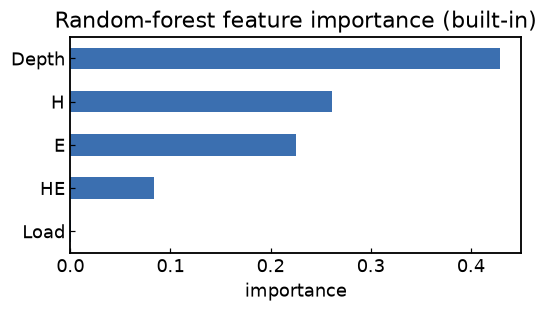

In [5]:
rf = RandomForestClassifier(n_estimators=200, random_state=0, n_jobs=-1).fit(Xtr, ytr)
gb = GradientBoostingClassifier(random_state=0).fit(Xtr, ytr)
print(pd.DataFrame({
    "model": ["decision tree", "random forest", "gradient boosting"],
    "test accuracy": [accuracy_score(yte, m.predict(Xte)) for m in (tree, rf, gb)]
}).round(3).to_string(index=False))

imp = pd.Series(rf.feature_importances_, index=features).sort_values()
fig, ax = plt.subplots(figsize=(5, 3)); imp.plot.barh(ax=ax, color="#3b6fb0")
ax.set_xlabel("importance"); ax.set_title("Random-forest feature importance (built-in)")
fig.tight_layout()

### 3b · A more honest importance: **permutation** importance

Built-in importance can be fooled (it favours features with many split points). A more
trustworthy check: **shuffle** one feature's values in the *test* set and see how much
the score drops. A big drop = the model genuinely relied on that feature.

> 🧠 **permutation importance** — measure a feature's importance by randomly shuffling it and watching the test score fall. It reflects what actually helps on unseen data, not just how the model was built.

> ✅ **When you run the next cell, you should see:** a bar chart of permutation importance. The ranking is broadly similar to the built-in one, but this version is measured on held-out data.

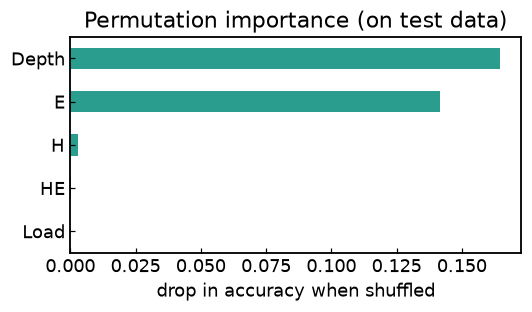

In [6]:
from sklearn.inspection import permutation_importance

# Shuffle each feature 10 times on a test subsample and average the accuracy drop.
sub = rng.choice(len(Xte), 3000, replace=False)          # subsample -> fast
r = permutation_importance(rf, Xte[sub], yte[sub], n_repeats=10,
                           random_state=0, n_jobs=-1)
pi = pd.Series(r.importances_mean, index=features).sort_values()

fig, ax = plt.subplots(figsize=(5, 3)); pi.plot.barh(ax=ax, color="#2a9d8f")
ax.set_xlabel("drop in accuracy when shuffled"); ax.set_title("Permutation importance (on test data)")
fig.tight_layout()

*🖼 **Figure.** Each bar is how much accuracy the forest loses when that feature is scrambled. Features whose bar is ~0 could be removed with little loss — a practical way to simplify a model.*

## 4 · The rare-phase problem, and SMOTE

Real maps often contain a phase that is only a **few percent** of indents. A model can then
score high **accuracy** while **missing that phase almost entirely** — because always
guessing 'matrix' is right 96% of the time. The metric that catches this is **recall**.

> 🧠 **class imbalance** — when one label is much rarer than another. Accuracy becomes misleading: a lazy 'always the common class' model looks great.

> 🧠 **recall (of the rare phase)** — of all the indents that truly are the rare phase, what fraction did we catch? This is what you must watch under imbalance.

> 🧠 **SMOTE** — Synthetic Minority Over-sampling: invents new rare-class examples *between* real ones to rebalance the training set, so the model stops ignoring them.

> ⚖️ **Accuracy vs recall — the key beginner lesson.** With a rare phase, *accuracy* can be
> 0.96 while *recall* of the rare phase is near 0. Always report recall (or a confusion matrix)
> for the minority class.

> ✅ **When you run the next cell, you should see:** the imbalanced training counts, then minority-phase **recall rising** once SMOTE is applied.

In [7]:
from imblearn.over_sampling import SMOTE

# Force a strong imbalance: keep only 4% of the intermetallic in TRAINING.
minor = np.where(ytr == 1)[0]; major = np.where(ytr == 0)[0]
keep = np.concatenate([major, rng.choice(minor, int(len(minor) * 0.04), replace=False)])
Xi, yi = Xtr[keep], ytr[keep]
print("imbalanced training counts:", {0: int((yi == 0).sum()), 1: int((yi == 1).sum())})

rf_imb = RandomForestClassifier(n_estimators=200, random_state=0, n_jobs=-1).fit(Xi, yi)
Xr, yr = SMOTE(random_state=0).fit_resample(Xi, yi)      # rebalance by synthesising minority
rf_smote = RandomForestClassifier(n_estimators=200, random_state=0, n_jobs=-1).fit(Xr, yr)

for name, m in [("no SMOTE", rf_imb), ("with SMOTE", rf_smote)]:
    r = recall_score(yte, m.predict(Xte), pos_label=1)  # recall of the rare phase
    print(f"{name:10s}  minority-phase recall = {r:.2f}")

imbalanced training counts: {0: 10456, 1: 701}


no SMOTE    minority-phase recall = 0.98
with SMOTE  minority-phase recall = 0.99


> 🧠 **confusion matrix** — a 2×2 table of predicted vs true labels: the off-diagonal cells are the mistakes. Great for seeing *which* errors a model makes.

> ✅ **When you run the next cell, you should see:** two confusion matrices side by side — SMOTE moves counts onto the diagonal for the rare phase (fewer missed intermetallic indents).

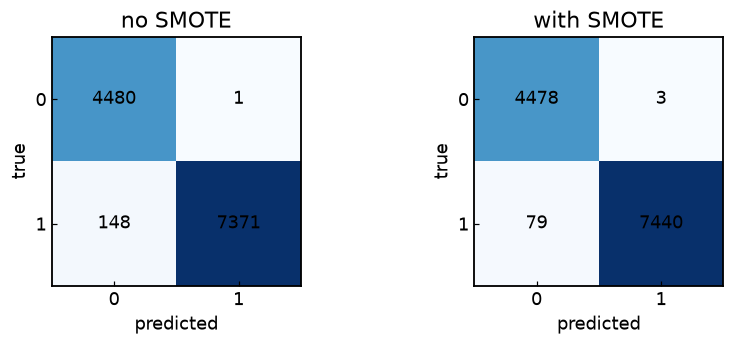

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(8, 3.3))
for a, (name, m) in zip(ax, [("no SMOTE", rf_imb), ("with SMOTE", rf_smote)]):
    cm = confusion_matrix(yte, m.predict(Xte))
    im = a.imshow(cm, cmap="Blues"); a.set_title(name)
    a.set_xticks([0, 1]); a.set_yticks([0, 1]); a.set_xlabel("predicted"); a.set_ylabel("true")
    for (i, j), v in np.ndenumerate(cm): a.text(j, i, f"{v}", ha="center", va="center")
fig.tight_layout()

## 5 · Why did it decide? SHAP

Feature *importance* is **global** (one number per feature, for the whole model). **SHAP**
is **local**: it splits each individual prediction into per-feature contributions, so you can
defend a phase call indent-by-indent.

> 🧠 **SHAP value** — for one prediction, how much each feature pushed it toward or away from a phase. Summing the pushes rebuilds the prediction.

> ✅ **When you run the next cell, you should see:** a bar chart of mean |SHAP|. Note that **Depth and E**, not only H, drive the phase call — a nice reminder that hardness isn't the whole story.

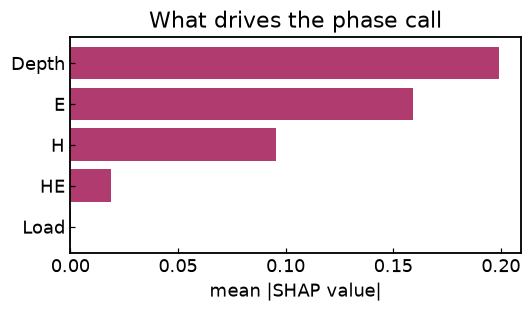

In [9]:
import shap
Xsub = Xte[rng.choice(len(Xte), 1500, replace=False)]   # explain a subsample (fast)
sv = shap.TreeExplainer(rf).shap_values(Xsub)
# Different SHAP versions return a list or a 3-D array; grab the positive class either way.
sv_pos = sv[1] if isinstance(sv, list) else (sv[..., 1] if getattr(sv, "ndim", 2) == 3 else sv)
imp = np.abs(sv_pos).mean(0)                             # average absolute contribution per feature
order = np.argsort(imp)

fig, ax = plt.subplots(figsize=(5, 3))
ax.barh(np.array(features)[order], imp[order], color="#b03b6f")
ax.set_xlabel("mean |SHAP value|"); ax.set_title("What drives the phase call"); fig.tight_layout()

*🖼 **Figure.** SHAP agrees the split is real but shows it leans on Depth and E as well as H. That is a genuine physical insight: the *whole* mechanical response distinguishes the phases, not hardness alone.*

## ✅ Recap
- A shallow **decision tree** is a human-readable rule set; **forests/boosting** trade some interpretability for accuracy.
- Ask 'which features matter?' two ways: **built-in** importance (how the model was built) and **permutation** importance (what actually helps on unseen data).
- A **rare phase** is the real danger — watch **recall**, not accuracy, and use **SMOTE**; **SHAP** explains single predictions.

## 🔧 Try it yourself
Small changes teach the most. Try these (re-run the cell after each):
1. Raise the tree's `max_depth` from 3 to 8. Does test accuracy improve, or does the tree just get harder to read (a sign of overfitting)?
2. In Section 4, change the minority keep-fraction from `0.04` to `0.01`. How low does no-SMOTE recall fall?
3. Drop the least-important feature (from Section 3b) and retrain the forest. Does accuracy change much?

## 🩹 Common errors & fixes
- **`ModuleNotFoundError: imblearn` / `shap`** → `pip install imbalanced-learn shap`.
- **SHAP cell is slow** → shrink the explained subsample (e.g. 800 instead of 1500).
- **Recall looks like 0.00 without SMOTE** → that's the lesson, not a bug: the model is ignoring the rare phase.

---
**Next:** open **`04_curve_as_image_cnn.ipynb`** — classify the *whole curve* with a CNN. (Or try **`03a_evaluating_models.ipynb`** first to learn how to trust these scores.)